# Instruction (Read this)
- Use this template to develop your project. Do not change the steps. 
- For each step, you may add additional cells if needed.
- But remove <b>unnecessary</b> cells to ensure the notebook is readable.
- Marks will be <b>deducted</b> if the notebook is cluttered or difficult to follow due to excess or irrelevant content.
- <b>Briefly</b> describe the steps in the "Description:" field.
- <b>Do not</b> submit the dataset. 
- The submitted jupyter notebook will be executed using the uploaded dataset in eLearn.

# Group Information

Group No:

- Member 1: CH'NG BAO SHENG (23302782)
- Member 2: LIM YONG ZHOU (23302902)
- Member 3: JEFFRY SOO YU ZHEN (23304759)

# Import Necessary Libraries

## Core Data Handling

In [1]:
import pandas as pd # for data manipulation

## Numerics and Array Operations

In [2]:
import numpy as np # for numerical operations

## Machine Learning Algorithms and Utilities

In [3]:
from sklearn.linear_model import LogisticRegression # for Logistic Regression classifier
from sklearn.svm import SVC # for Support Vector Machine classifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score # for splitting data and cross-validation
from sklearn.preprocessing import StandardScaler # for feature scaling
from sklearn.feature_selection import SequentialFeatureSelector # for Sequential Feature Selection

## Visualization

In [4]:
import matplotlib.pyplot as plt # for plotting graphs
import seaborn as sns # for enhanced data visualization

# Load the Dataset

In [5]:
# Define column names based on the Dermatology dataset README
columns = [
    'erythema',
    'scaling',
    'definite_borders',
    'itching',
    'koebner_phenomenon',
    'polygonal_papules',
    'follicular_papules',
    'oral_mucosal_involvement',
    'knee_and_elbow_involvement',
    'scalp_involvement',
    'family_history',
    'melanin_incontinence',
    'eosinophils_in_the_infiltrate',
    'PNL_infiltrate',
    'fibrosis_of_the_papillary_dermis',
    'exocytosis',
    'acanthosis',
    'hyperkeratosis',
    'parakeratosis',
    'clubbing_of_the_rete_ridges',
    'elongation_of_the_rete_ridges',
    'thinning_of_the_suprapapillary_epidermis',
    'spongiform_pustule',
    'munro_microabcess',
    'focal_hypergranulosis',
    'disappearance_of_the_granular_layer',
    'vacuolisation_and_damage_of_basal_layer',
    'spongiosis',
    'saw_tooth_appearance_of_retes',
    'follicular_horn_plug',
    'perifollicular_parakeratosis',
    'inflammatory_mononuclear_infiltrate',
    'band_like_infiltrate',
    'age',
    'class'
]

# Load the dataset without headers and convert '?' missing values to NaN
df = pd.read_csv(
    'Project Datasets/Dermatology/dermatology.csv',
    header=None,
    names=columns,
    na_values='?'
)

# Display the first five rows of the dataset
df.head()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw_tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_mononuclear_infiltrate,band_like_infiltrate,age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55.0,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8.0,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26.0,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40.0,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45.0,3


# Exploratory Data Analysis (EDA)

## Initial Analysis of Dataset

In [6]:
print('Dataset dimension:', df.shape) # Display the number of rows and columns
print('Number of features:', df.drop(columns=['class']).shape[1]) # Display the number of input features
print('Columns of features:', df.drop(columns=['class']).columns) # Display all feature column names
print('Target column: class') # Display the target column name

Dataset dimension: (366, 35)
Number of features: 34
Columns of features: Index(['erythema', 'scaling', 'definite_borders', 'itching',
       'koebner_phenomenon', 'polygonal_papules', 'follicular_papules',
       'oral_mucosal_involvement', 'knee_and_elbow_involvement',
       'scalp_involvement', 'family_history', 'melanin_incontinence',
       'eosinophils_in_the_infiltrate', 'PNL_infiltrate',
       'fibrosis_of_the_papillary_dermis', 'exocytosis', 'acanthosis',
       'hyperkeratosis', 'parakeratosis', 'clubbing_of_the_rete_ridges',
       'elongation_of_the_rete_ridges',
       'thinning_of_the_suprapapillary_epidermis', 'spongiform_pustule',
       'munro_microabcess', 'focal_hypergranulosis',
       'disappearance_of_the_granular_layer',
       'vacuolisation_and_damage_of_basal_layer', 'spongiosis',
       'saw_tooth_appearance_of_retes', 'follicular_horn_plug',
       'perifollicular_parakeratosis', 'inflammatory_mononuclear_infiltrate',
       'band_like_infiltrate', 'age'],


## Data Types of Dataset

In [7]:
df.info() # Display column names, data types and non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 35 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   erythema                                  366 non-null    int64  
 1   scaling                                   366 non-null    int64  
 2   definite_borders                          366 non-null    int64  
 3   itching                                   366 non-null    int64  
 4   koebner_phenomenon                        366 non-null    int64  
 5   polygonal_papules                         366 non-null    int64  
 6   follicular_papules                        366 non-null    int64  
 7   oral_mucosal_involvement                  366 non-null    int64  
 8   knee_and_elbow_involvement                366 non-null    int64  
 9   scalp_involvement                         366 non-null    int64  
 10  family_history                        

## Descriptive Statistics for Numeric Columns

In [8]:
df.describe() # Display descriptive statistics for numeric columns

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw_tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_mononuclear_infiltrate,band_like_infiltrate,age,class
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,...,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,358.000000,366.000000
mean,2.068306,1.795082,1.549180,1.366120,0.633880,0.448087,0.166667,0.377049,0.614754,0.519126,...,0.464481,0.456284,0.953552,0.453552,0.103825,0.114754,1.866120,0.554645,36.296089,2.803279
std,0.664753,0.701527,0.907525,1.138299,0.908016,0.957327,0.570588,0.834147,0.982979,0.905639,...,0.864899,0.954873,1.130172,0.954744,0.450433,0.488723,0.726108,1.105908,15.324557,1.597803
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,25.000000,1.000000
50%,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,35.000000,3.000000
75%,2.000000,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,2.000000,0.000000,49.750000,4.000000
max,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,75.000000,6.000000


# Data Preparation
______________________________________________________________________________________
Description: Missing values, duplicate rows, and outlier considerations are handled before checking the final class distribution and splitting the dataset.

## Data Cleaning

### Handling Missing Values

In [9]:
missing_counts = df.isnull().sum() # Count missing values for each column
missing_counts[missing_counts > 0] # Display only columns with missing values

age    8
dtype: int64

In [10]:
age_median = df['age'].median() # Calculate the median age for imputation
df['age'] = df['age'].fillna(age_median) # Replace missing age values with the median age

print('Median age used for imputation:', age_median) # Display the median value used
print('Total missing values after imputation:', df.isnull().sum().sum()) # Check remaining missing values

Median age used for imputation: 35.0
Total missing values after imputation: 0


### Handling Duplicate Rows

In [11]:
duplicate_count = df.duplicated().sum() # Count duplicate rows in the dataset
print('Number of duplicate rows:', duplicate_count) # Display the number of duplicated rows

# Remove duplicate rows if any are found
if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True) # Drop duplicates and reset the index
    print('Duplicates removed. New dataset dimension:', df.shape) # Display new dataset dimension
else:
    print('No duplicate rows were found.') # Inform that no duplicates were found

Number of duplicate rows: 0
No duplicate rows were found.


## Outlier Checking
Most dermatology features are ordinal clinical or histopathological scores from 0 to 3. Therefore, values in this range are valid medical severity levels rather than statistical outliers. Only `age` is inspected separately, and rows are not removed using IQR to avoid deleting valid medical cases from a small dataset.

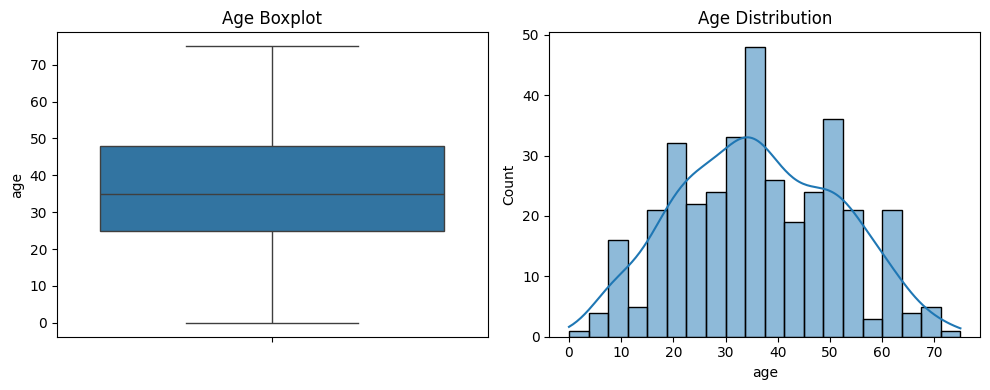

In [12]:
plt.figure(figsize=(10, 4)) # Set the figure size for side-by-side plots

plt.subplot(1, 2, 1) # Create the first subplot for boxplot
sns.boxplot(y=df['age']) # Plot age values to inspect possible outliers
plt.title('Age Boxplot') # Set title for the boxplot

plt.subplot(1, 2, 2) # Create the second subplot for histogram
sns.histplot(df['age'], bins=20, kde=True) # Plot the distribution of age
plt.title('Age Distribution') # Set title for the histogram

plt.tight_layout() # Adjust layout to prevent overlapping
plt.show() # Display the plots

## Class Distribution After Cleaning

In [13]:
# Define class labels based on the Dermatology dataset README
class_names = {
    1: 'psoriasis',
    2: 'seboreic dermatitis',
    3: 'lichen planus',
    4: 'pityriasis rosea',
    5: 'cronic dermatitis',
    6: 'pityriasis rubra pilaris'
}

# Count the number of instances for each disease class after cleaning
class_distribution = df['class'].value_counts().sort_index()

# Convert the class distribution into a DataFrame for clearer display
class_distribution_df = class_distribution.rename_axis('class').reset_index(name='count')

# Map each class number to its disease name
class_distribution_df['disease'] = class_distribution_df['class'].map(class_names)

# Display the final class distribution table before splitting
class_distribution_df

,class,count,disease
0,1,112,psoriasis
1,2,61,seboreic dermatitis
2,3,72,lichen planus
3,4,49,pityriasis rosea
4,5,52,cronic dermatitis
5,6,20,pityriasis rubra pilaris


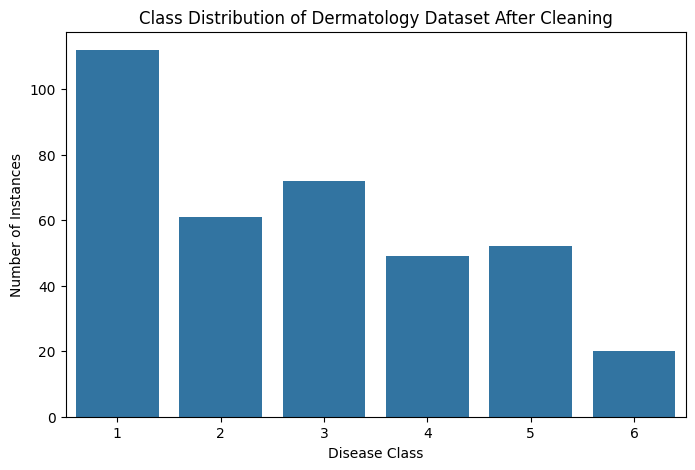

In [14]:
plt.figure(figsize=(8, 5)) # Set the figure size
sns.countplot(data=df, x='class', order=sorted(df['class'].unique())) # Plot the number of records for each class
plt.title('Class Distribution of Dermatology Dataset After Cleaning') # Set the chart title
plt.xlabel('Disease Class') # Set x-axis label
plt.ylabel('Number of Instances') # Set y-axis label
plt.show() # Display the plot

# Split the Dataset
Split the dataset into training, validation, and test sets. Three stratified split ratios are prepared: 80/10/10, 70/15/15, and 60/20/20.

In [15]:
X = df.drop(columns=['class']) # Select all input features
y = df['class'] # Select the multi-class target variable

print('All feature data types:') # Display the data types of all input features
print(X.dtypes.value_counts()) # Count the number of columns for each data type
print('\nTarget classes:', sorted(y.unique())) # Display unique target classes

All feature data types:
int64      33
float64     1
Name: count, dtype: int64

Target classes: [1, 2, 3, 4, 5, 6]


In [16]:
# Split the dataset into 80% training data and 20% temporary data for the 80/10/10 split
x_train_80, x_temp_20_for_80, y_train_80, y_temp_20_for_80 = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Split the temporary 20% data equally into 10% validation data and 10% test data
x_val_10, x_test_10, y_val_10, y_test_10 = train_test_split(
    x_temp_20_for_80,
    y_temp_20_for_80,
    test_size=0.50,
    random_state=42,
    stratify=y_temp_20_for_80
)

# Split the dataset into 70% training data and 30% temporary data for the 70/15/15 split
x_train_70, x_temp_30_for_70, y_train_70, y_temp_30_for_70 = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Split the temporary 30% data equally into 15% validation data and 15% test data
x_val_15, x_test_15, y_val_15, y_test_15 = train_test_split(
    x_temp_30_for_70,
    y_temp_30_for_70,
    test_size=0.50,
    random_state=42,
    stratify=y_temp_30_for_70
)

# Split the dataset into 60% training data and 40% temporary data for the 60/20/20 split
x_train_60, x_temp_40_for_60, y_train_60, y_temp_40_for_60 = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=42,
    stratify=y
)

# Split the temporary 40% data equally into 20% validation data and 20% test data
x_val_20, x_test_20, y_val_20, y_test_20 = train_test_split(
    x_temp_40_for_60,
    y_temp_40_for_60,
    test_size=0.50,
    random_state=42,
    stratify=y_temp_40_for_60
)

# Store all explicit split variables in a dictionary for easier looping in later preprocessing steps
split_datasets = {
    '80_10_10': {
        'X_train': x_train_80,
        'X_val': x_val_10,
        'X_test': x_test_10,
        'y_train': y_train_80,
        'y_val': y_val_10,
        'y_test': y_test_10
    },
    '70_15_15': {
        'X_train': x_train_70,
        'X_val': x_val_15,
        'X_test': x_test_15,
        'y_train': y_train_70,
        'y_val': y_val_15,
        'y_test': y_test_15
    },
    '60_20_20': {
        'X_train': x_train_60,
        'X_val': x_val_20,
        'X_test': x_test_20,
        'y_train': y_train_60,
        'y_val': y_val_20,
        'y_test': y_test_20
    }
}

# Display the dimensions of each explicit split dataset
print('80/10/10 split')
print('x_train_80:', x_train_80.shape, 'y_train_80:', y_train_80.shape)
print('x_val_10:', x_val_10.shape, 'y_val_10:', y_val_10.shape)
print('x_test_10:', x_test_10.shape, 'y_test_10:', y_test_10.shape)
print('-' * 50)

print('70/15/15 split')
print('x_train_70:', x_train_70.shape, 'y_train_70:', y_train_70.shape)
print('x_val_15:', x_val_15.shape, 'y_val_15:', y_val_15.shape)
print('x_test_15:', x_test_15.shape, 'y_test_15:', y_test_15.shape)
print('-' * 50)

print('60/20/20 split')
print('x_train_60:', x_train_60.shape, 'y_train_60:', y_train_60.shape)
print('x_val_20:', x_val_20.shape, 'y_val_20:', y_val_20.shape)
print('x_test_20:', x_test_20.shape, 'y_test_20:', y_test_20.shape)

80/10/10 split
x_train_80: (292, 34) y_train_80: (292,)
x_val_10: (37, 34) y_val_10: (37,)
x_test_10: (37, 34) y_test_10: (37,)
--------------------------------------------------
70/15/15 split
x_train_70: (256, 34) y_train_70: (256,)
x_val_15: (55, 34) y_val_15: (55,)
x_test_15: (55, 34) y_test_15: (55,)
--------------------------------------------------
60/20/20 split
x_train_60: (219, 34) y_train_60: (219,)
x_val_20: (73, 34) y_val_20: (73,)
x_test_20: (74, 34) y_test_20: (74,)


In [17]:
# Display the class distribution for each train, validation and test split
for split_name, data in split_datasets.items():
    split_distribution = pd.DataFrame({
        'train': data['y_train'].value_counts().sort_index(),
        'validation': data['y_val'].value_counts().sort_index(),
        'test': data['y_test'].value_counts().sort_index()
    })

    print(f'Class distribution for {split_name} split') # Display split name
    display(split_distribution) # Display the class distribution table for the split

Class distribution for 80_10_10 split


,train,validation,test
class,,,
1,89,11,12
2,49,6,6
3,57,8,7
4,39,5,5
5,42,5,5
6,16,2,2


Class distribution for 70_15_15 split


,train,validation,test
class,,,
1,78,17,17
2,43,9,9
3,50,11,11
4,34,7,8
5,37,8,7
6,14,3,3


Class distribution for 60_20_20 split


,train,validation,test
class,,,
1,67,22,23
2,37,12,12
3,43,14,15
4,29,10,10
5,31,11,10
6,12,4,4


In [18]:
# Use the 70/15/15 split as the default split for the remaining preprocessing examples
X_train = x_train_70 # Default training features
X_val = x_val_15 # Default validation features
X_test = x_test_15 # Default test features
y_train = y_train_70 # Default training target
y_val = y_val_15 # Default validation target
y_test = y_test_15 # Default test target

# Data Preprocessing
Perform data preprocessing such as normalization, standardization, label encoding etc.
______________________________________________________________________________________
Description: Label encoding is not required because all attributes and class labels are already numeric. Standardization is applied after splitting. Each scaler is fitted only on its training set, then applied to the matching validation and test sets to avoid data leakage.

In [19]:
# Create separate StandardScaler objects for each split ratio
scaler_80_10_10 = StandardScaler() # Scaler for 80/10/10 split
scaler_70_15_15 = StandardScaler() # Scaler for 70/15/15 split
scaler_60_20_20 = StandardScaler() # Scaler for 60/20/20 split

# Fit the scaler on 80% training data and transform the matching validation and test data
x_train_80_scaled = scaler_80_10_10.fit_transform(x_train_80) # Fit and transform 80% training features
x_val_10_scaled = scaler_80_10_10.transform(x_val_10) # Transform 10% validation features
x_test_10_scaled = scaler_80_10_10.transform(x_test_10) # Transform 10% test features

# Convert the 80/10/10 scaled arrays back into DataFrames
x_train_80_scaled_df = pd.DataFrame(x_train_80_scaled, columns=X.columns, index=x_train_80.index)
x_val_10_scaled_df = pd.DataFrame(x_val_10_scaled, columns=X.columns, index=x_val_10.index)
x_test_10_scaled_df = pd.DataFrame(x_test_10_scaled, columns=X.columns, index=x_test_10.index)

# Fit the scaler on 70% training data and transform the matching validation and test data
x_train_70_scaled = scaler_70_15_15.fit_transform(x_train_70) # Fit and transform 70% training features
x_val_15_scaled = scaler_70_15_15.transform(x_val_15) # Transform 15% validation features
x_test_15_scaled = scaler_70_15_15.transform(x_test_15) # Transform 15% test features

# Convert the 70/15/15 scaled arrays back into DataFrames
x_train_70_scaled_df = pd.DataFrame(x_train_70_scaled, columns=X.columns, index=x_train_70.index)
x_val_15_scaled_df = pd.DataFrame(x_val_15_scaled, columns=X.columns, index=x_val_15.index)
x_test_15_scaled_df = pd.DataFrame(x_test_15_scaled, columns=X.columns, index=x_test_15.index)

# Fit the scaler on 60% training data and transform the matching validation and test data
x_train_60_scaled = scaler_60_20_20.fit_transform(x_train_60) # Fit and transform 60% training features
x_val_20_scaled = scaler_60_20_20.transform(x_val_20) # Transform 20% validation features
x_test_20_scaled = scaler_60_20_20.transform(x_test_20) # Transform 20% test features

# Convert the 60/20/20 scaled arrays back into DataFrames
x_train_60_scaled_df = pd.DataFrame(x_train_60_scaled, columns=X.columns, index=x_train_60.index)
x_val_20_scaled_df = pd.DataFrame(x_val_20_scaled, columns=X.columns, index=x_val_20.index)
x_test_20_scaled_df = pd.DataFrame(x_test_20_scaled, columns=X.columns, index=x_test_20.index)

# Store all explicit scaled variables in a dictionary for easier looping in later model training
scaled_datasets = {
    '80_10_10': {
        'X_train_scaled': x_train_80_scaled_df,
        'X_val_scaled': x_val_10_scaled_df,
        'X_test_scaled': x_test_10_scaled_df,
        'y_train': y_train_80,
        'y_val': y_val_10,
        'y_test': y_test_10,
        'scaler': scaler_80_10_10
    },
    '70_15_15': {
        'X_train_scaled': x_train_70_scaled_df,
        'X_val_scaled': x_val_15_scaled_df,
        'X_test_scaled': x_test_15_scaled_df,
        'y_train': y_train_70,
        'y_val': y_val_15,
        'y_test': y_test_15,
        'scaler': scaler_70_15_15
    },
    '60_20_20': {
        'X_train_scaled': x_train_60_scaled_df,
        'X_val_scaled': x_val_20_scaled_df,
        'X_test_scaled': x_test_20_scaled_df,
        'y_train': y_train_60,
        'y_val': y_val_20,
        'y_test': y_test_20,
        'scaler': scaler_60_20_20
    }
}

# Display the first five rows of the scaled training features for the default 70/15/15 split
x_train_70_scaled_df.head()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,focal_hypergranulosis,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw_tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_mononuclear_infiltrate,band_like_infiltrate,age
273,-0.072286,0.268991,1.576253,-0.343212,-0.678289,-0.462741,-0.299271,-0.448523,2.461330,1.769005,...,-0.474377,1.751751,-0.482668,-0.888264,-0.470526,-0.23858,-0.233493,1.545793,-0.503066,1.348490
317,-0.072286,0.268991,0.485656,-1.239765,0.449256,-0.462741,-0.299271,-0.448523,1.430069,1.769005,...,-0.474377,1.751751,-0.482668,-0.888264,-0.470526,-0.23858,-0.233493,0.181231,-0.503066,0.696036
46,-0.072286,-1.136351,-0.604940,1.449894,2.704347,-0.462741,-0.299271,-0.448523,-0.632453,-0.577447,...,-0.474377,-0.524636,-0.482668,-0.003456,-0.470526,-0.23858,-0.233493,0.181231,-0.503066,0.630791
270,-0.072286,0.268991,-0.604940,-1.239765,0.449256,-0.462741,-0.299271,-0.448523,-0.632453,-0.577447,...,-0.474377,0.613558,-0.482668,1.766158,-0.470526,-0.23858,-0.233493,0.181231,-0.503066,1.674717
256,-0.072286,-1.136351,-0.604940,-1.239765,0.449256,-0.462741,-0.299271,-0.448523,-0.632453,-0.577447,...,-0.474377,0.613558,-0.482668,0.881351,-0.470526,-0.23858,-0.233493,-1.183331,-0.503066,-0.086909


In [20]:
# Store default scaled datasets for easier use in the next preprocessing steps
X_train_scaled_df = x_train_70_scaled_df # Default scaled training features
X_val_scaled_df = x_val_15_scaled_df # Default scaled validation features
X_test_scaled_df = x_test_15_scaled_df # Default scaled test features

## Prepare Datasets for Logistic Regression and SVM
Logistic Regression and SVM are sensitive to feature scale, so the scaled datasets are prepared for both algorithms. The same train, validation and test splits are reused to ensure a fair comparison.

In [21]:
# Prepare explicit scaled datasets for Logistic Regression using 80/10/10 split
lr_x_train_80 = x_train_80_scaled_df # Logistic Regression training features for 80/10/10 split
lr_x_val_10 = x_val_10_scaled_df # Logistic Regression validation features for 80/10/10 split
lr_x_test_10 = x_test_10_scaled_df # Logistic Regression test features for 80/10/10 split
lr_y_train_80 = y_train_80 # Logistic Regression training target for 80/10/10 split
lr_y_val_10 = y_val_10 # Logistic Regression validation target for 80/10/10 split
lr_y_test_10 = y_test_10 # Logistic Regression test target for 80/10/10 split

# Prepare explicit scaled datasets for Logistic Regression using 70/15/15 split
lr_x_train_70 = x_train_70_scaled_df # Logistic Regression training features for 70/15/15 split
lr_x_val_15 = x_val_15_scaled_df # Logistic Regression validation features for 70/15/15 split
lr_x_test_15 = x_test_15_scaled_df # Logistic Regression test features for 70/15/15 split
lr_y_train_70 = y_train_70 # Logistic Regression training target for 70/15/15 split
lr_y_val_15 = y_val_15 # Logistic Regression validation target for 70/15/15 split
lr_y_test_15 = y_test_15 # Logistic Regression test target for 70/15/15 split

# Prepare explicit scaled datasets for Logistic Regression using 60/20/20 split
lr_x_train_60 = x_train_60_scaled_df # Logistic Regression training features for 60/20/20 split
lr_x_val_20 = x_val_20_scaled_df # Logistic Regression validation features for 60/20/20 split
lr_x_test_20 = x_test_20_scaled_df # Logistic Regression test features for 60/20/20 split
lr_y_train_60 = y_train_60 # Logistic Regression training target for 60/20/20 split
lr_y_val_20 = y_val_20 # Logistic Regression validation target for 60/20/20 split
lr_y_test_20 = y_test_20 # Logistic Regression test target for 60/20/20 split

# Prepare explicit scaled datasets for SVM using 80/10/10 split
svm_x_train_80 = x_train_80_scaled_df # SVM training features for 80/10/10 split
svm_x_val_10 = x_val_10_scaled_df # SVM validation features for 80/10/10 split
svm_x_test_10 = x_test_10_scaled_df # SVM test features for 80/10/10 split
svm_y_train_80 = y_train_80 # SVM training target for 80/10/10 split
svm_y_val_10 = y_val_10 # SVM validation target for 80/10/10 split
svm_y_test_10 = y_test_10 # SVM test target for 80/10/10 split

# Prepare explicit scaled datasets for SVM using 70/15/15 split
svm_x_train_70 = x_train_70_scaled_df # SVM training features for 70/15/15 split
svm_x_val_15 = x_val_15_scaled_df # SVM validation features for 70/15/15 split
svm_x_test_15 = x_test_15_scaled_df # SVM test features for 70/15/15 split
svm_y_train_70 = y_train_70 # SVM training target for 70/15/15 split
svm_y_val_15 = y_val_15 # SVM validation target for 70/15/15 split
svm_y_test_15 = y_test_15 # SVM test target for 70/15/15 split

# Prepare explicit scaled datasets for SVM using 60/20/20 split
svm_x_train_60 = x_train_60_scaled_df # SVM training features for 60/20/20 split
svm_x_val_20 = x_val_20_scaled_df # SVM validation features for 60/20/20 split
svm_x_test_20 = x_test_20_scaled_df # SVM test features for 60/20/20 split
svm_y_train_60 = y_train_60 # SVM training target for 60/20/20 split
svm_y_val_20 = y_val_20 # SVM validation target for 60/20/20 split
svm_y_test_20 = y_test_20 # SVM test target for 60/20/20 split

# Create dictionaries to store model-ready datasets for Logistic Regression and SVM
logistic_regression_datasets = {
    '80_10_10': {'X_train': lr_x_train_80, 'X_val': lr_x_val_10, 'X_test': lr_x_test_10, 'y_train': lr_y_train_80, 'y_val': lr_y_val_10, 'y_test': lr_y_test_10},
    '70_15_15': {'X_train': lr_x_train_70, 'X_val': lr_x_val_15, 'X_test': lr_x_test_15, 'y_train': lr_y_train_70, 'y_val': lr_y_val_15, 'y_test': lr_y_test_15},
    '60_20_20': {'X_train': lr_x_train_60, 'X_val': lr_x_val_20, 'X_test': lr_x_test_20, 'y_train': lr_y_train_60, 'y_val': lr_y_val_20, 'y_test': lr_y_test_20}
}

svm_datasets = {
    '80_10_10': {'X_train': svm_x_train_80, 'X_val': svm_x_val_10, 'X_test': svm_x_test_10, 'y_train': svm_y_train_80, 'y_val': svm_y_val_10, 'y_test': svm_y_test_10},
    '70_15_15': {'X_train': svm_x_train_70, 'X_val': svm_x_val_15, 'X_test': svm_x_test_15, 'y_train': svm_y_train_70, 'y_val': svm_y_val_15, 'y_test': svm_y_test_15},
    '60_20_20': {'X_train': svm_x_train_60, 'X_val': svm_x_val_20, 'X_test': svm_x_test_20, 'y_train': svm_y_train_60, 'y_val': svm_y_val_20, 'y_test': svm_y_test_20}
}

print('Prepared explicit Logistic Regression datasets for 80/10/10, 70/15/15 and 60/20/20 splits.') # Display Logistic Regression preparation status
print('Prepared explicit SVM datasets for 80/10/10, 70/15/15 and 60/20/20 splits.') # Display SVM preparation status

Prepared explicit Logistic Regression datasets for 80/10/10, 70/15/15 and 60/20/20 splits.
Prepared explicit SVM datasets for 80/10/10, 70/15/15 and 60/20/20 splits.


In [22]:
# Initialize model objects for later model training
logistic_regression_model = LogisticRegression(max_iter=1000, random_state=42) # Create Logistic Regression model
svm_model = SVC(kernel='rbf', random_state=42) # Create SVM model with RBF kernel

print(logistic_regression_model) # Display Logistic Regression model configuration
print(svm_model) # Display SVM model configuration

LogisticRegression(max_iter=1000, random_state=42)
SVC(random_state=42)


# Feature Selection
Perform feature selection to select the relevant features.
______________________________________________________________________________________
Description: Forward Sequential Feature Selection is applied separately for Logistic Regression and SVM with an RBF kernel across all three split ratios. A smaller set of candidate feature counts is tested first to reduce runtime while still showing the relationship between feature count and 5-fold cross-validation accuracy.

In [23]:
# Create a stratified 5-fold cross-validation object to preserve class proportions in each fold
sfs_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Use fewer candidate k values first to reduce SFS runtime
candidate_feature_counts = [5, 10, 15, 20, 25, 30, X_train_scaled_df.shape[1]]

# Remove duplicate candidate values and keep only valid feature counts
feature_counts = sorted(set(k for k in candidate_feature_counts if 1 <= k <= X_train_scaled_df.shape[1]))

# Define the two models used for Sequential Feature Selection
sfs_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42), # Logistic Regression model
    'SVM RBF': SVC(kernel='rbf', random_state=42) # SVM model using the RBF kernel
}

# Store all scaled training datasets for all three split ratios
sfs_input_data = {
    '80_10_10': {
        'Logistic Regression': {'X_train': lr_x_train_80, 'y_train': lr_y_train_80},
        'SVM RBF': {'X_train': svm_x_train_80, 'y_train': svm_y_train_80}
    },
    '70_15_15': {
        'Logistic Regression': {'X_train': lr_x_train_70, 'y_train': lr_y_train_70},
        'SVM RBF': {'X_train': svm_x_train_70, 'y_train': svm_y_train_70}
    },
    '60_20_20': {
        'Logistic Regression': {'X_train': lr_x_train_60, 'y_train': lr_y_train_60},
        'SVM RBF': {'X_train': svm_x_train_60, 'y_train': svm_y_train_60}
    }
}

# Create empty containers to store detailed SFS results and summary rows
sfs_results = {}
sfs_summary_rows = []

# Loop through each split ratio so feature selection can be compared across training sizes
for split_name, split_data in sfs_input_data.items():
    sfs_results[split_name] = {}

    # Loop through each model so Logistic Regression and SVM are evaluated separately
    for model_name, model in sfs_models.items():
        X_sfs = split_data[model_name]['X_train'] # Select the scaled training features for the current split and model
        y_sfs = split_data[model_name]['y_train'] # Select the training target values for the current split and model
        model_results = [] # Store all candidate-k results for the current split and model

        # Test each candidate number of selected features
        for k in feature_counts:
            # If k equals the total number of features, use all features without running SFS
            if k == X_sfs.shape[1]:
                selected_indices = np.arange(X_sfs.shape[1]) # Store all feature indices
                selected_features = X_sfs.columns.tolist() # Store all feature names
                selected_X = X_sfs # Use the full feature set
            else:
                # Initialize Forward Sequential Feature Selection for the current number of features
                sfs = SequentialFeatureSelector(
                    estimator=model,
                    n_features_to_select=k,
                    direction='forward',
                    scoring='accuracy',
                    cv=sfs_cv,
                    n_jobs=-1
                )

                # Fit SFS on the current training split to identify the best k features
                sfs.fit(X_sfs, y_sfs)

                # Get the selected feature mask, indices, names and feature subset
                selected_mask = sfs.get_support()
                selected_indices = np.where(selected_mask)[0]
                selected_features = X_sfs.columns[selected_mask].tolist()
                selected_X = X_sfs.iloc[:, selected_indices]

            # Evaluate the selected feature subset using 5-fold cross-validation accuracy
            cv_scores = cross_val_score(
                model,
                selected_X,
                y_sfs,
                scoring='accuracy',
                cv=sfs_cv,
                n_jobs=-1
            )

            # Save the candidate-k result for the current split and model
            model_results.append({
                'split_ratio': split_name,
                'model': model_name,
                'number_of_features': k,
                'cv_accuracy': cv_scores.mean(),
                'cv_std': cv_scores.std(),
                'selected_indices': selected_indices.tolist(),
                'selected_features': selected_features
            })

            # Print progress so the long-running SFS process can be monitored
            print(f'{split_name} | {model_name} | k={k} | CV accuracy={cv_scores.mean():.4f}')

        # Convert the detailed results into a DataFrame for easier viewing and plotting
        result_df = pd.DataFrame(model_results)
        sfs_results[split_name][model_name] = result_df

        # Store the best candidate-k row for the current split and model
        best_row = result_df.loc[result_df['cv_accuracy'].idxmax()]
        sfs_summary_rows.append(best_row)

# Combine the best rows into one summary table
sfs_summary_df = pd.DataFrame(sfs_summary_rows).reset_index(drop=True)

# Display the summary table for all split and model combinations
sfs_summary_df[['split_ratio', 'model', 'number_of_features', 'cv_accuracy', 'cv_std', 'selected_indices', 'selected_features']]

80_10_10 | Logistic Regression | k=5 | CV accuracy=0.9007
80_10_10 | Logistic Regression | k=10 | CV accuracy=0.9931
80_10_10 | Logistic Regression | k=15 | CV accuracy=0.9931
80_10_10 | Logistic Regression | k=20 | CV accuracy=0.9931
80_10_10 | Logistic Regression | k=25 | CV accuracy=0.9931
80_10_10 | Logistic Regression | k=30 | CV accuracy=0.9862
80_10_10 | Logistic Regression | k=34 | CV accuracy=0.9760
80_10_10 | SVM RBF | k=5 | CV accuracy=0.9248
80_10_10 | SVM RBF | k=10 | CV accuracy=0.9794
80_10_10 | SVM RBF | k=15 | CV accuracy=0.9897
80_10_10 | SVM RBF | k=20 | CV accuracy=0.9898
80_10_10 | SVM RBF | k=25 | CV accuracy=0.9898
80_10_10 | SVM RBF | k=30 | CV accuracy=0.9898
80_10_10 | SVM RBF | k=34 | CV accuracy=0.9760
70_15_15 | Logistic Regression | k=5 | CV accuracy=0.9649
70_15_15 | Logistic Regression | k=10 | CV accuracy=0.9882
70_15_15 | Logistic Regression | k=15 | CV accuracy=0.9922
70_15_15 | Logistic Regression | k=20 | CV accuracy=0.9922
70_15_15 | Logistic Regre

,split_ratio,model,number_of_features,cv_accuracy,cv_std,selected_indices,selected_features
0,80_10_10,Logistic Regression,10,0.993103,0.013793,"[4, 6, 8, 13, 14, 17, 20, 25, 26, 27]","[koebner_phenomenon, follicular_papules, knee_..."
1,80_10_10,SVM RBF,20,0.989772,0.008352,"[0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 13, 14, 19, 20...","[erythema, scaling, definite_borders, itching,..."
2,70_15_15,Logistic Regression,15,0.992157,0.009606,"[4, 6, 8, 9, 10, 11, 13, 14, 18, 19, 20, 24, 2...","[koebner_phenomenon, follicular_papules, knee_..."
3,70_15_15,SVM RBF,20,0.988311,0.009545,"[0, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 17, ...","[erythema, koebner_phenomenon, polygonal_papul..."
4,60_20_20,Logistic Regression,10,0.986364,0.018182,"[1, 2, 4, 6, 11, 13, 14, 21, 26, 27]","[scaling, definite_borders, koebner_phenomenon..."
5,60_20_20,SVM RBF,10,0.986364,0.011134,"[1, 2, 4, 6, 11, 13, 14, 19, 25, 27]","[scaling, definite_borders, koebner_phenomenon..."


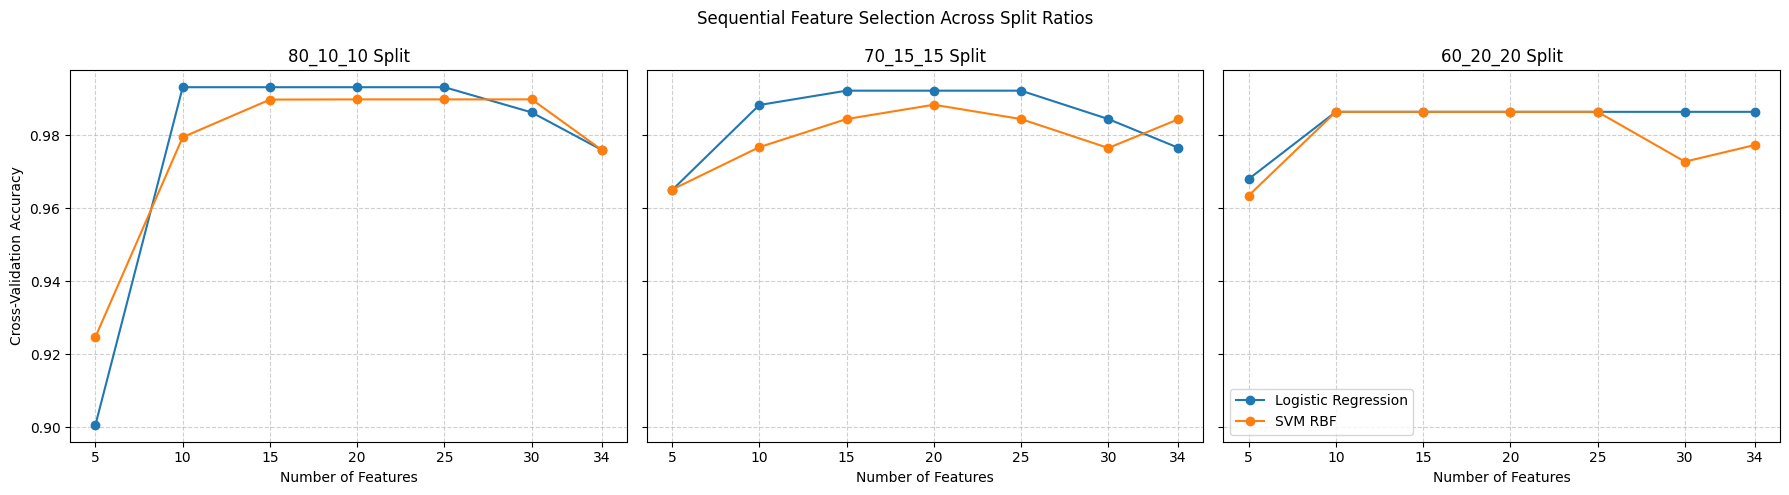

In [24]:
# Create subplots to compare feature count against cross-validation accuracy for each split ratio
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Plot one chart per split ratio
for ax, split_name in zip(axes, sfs_results.keys()):
    # Plot one accuracy curve for each model within the current split ratio
    for model_name, result_df in sfs_results[split_name].items():
        ax.plot(
            result_df['number_of_features'],
            result_df['cv_accuracy'],
            marker='o',
            label=model_name
        )

    # Add title, labels, ticks and grid for the current subplot
    ax.set_title(f'{split_name} Split')
    ax.set_xlabel('Number of Features')
    ax.set_xticks(feature_counts)
    ax.grid(True, linestyle='--', alpha=0.6)

# Add a shared y-axis label and legend
axes[0].set_ylabel('Cross-Validation Accuracy')
axes[-1].legend()

# Add an overall title for all three split-ratio plots
fig.suptitle('Sequential Feature Selection Across Split Ratios')
plt.tight_layout()
plt.show()

In [25]:
# Create dictionaries to store the best SFS result for each split ratio and each model
lr_sfs_optimal_results = {}
svm_sfs_optimal_results = {}

# Keep the split order consistent with the earlier train/validation/test split section
split_order = ['80_10_10', '70_15_15', '60_20_20']

# Loop through each split ratio to extract the best Logistic Regression and SVM RBF SFS results
for split_name in split_order:
    # Select the best Logistic Regression row for the current split ratio
    lr_row = sfs_summary_df[
        (sfs_summary_df['split_ratio'] == split_name) &
        (sfs_summary_df['model'] == 'Logistic Regression')
    ].iloc[0]

    # Select the best SVM RBF row for the current split ratio
    svm_row = sfs_summary_df[
        (sfs_summary_df['split_ratio'] == split_name) &
        (sfs_summary_df['model'] == 'SVM RBF')
    ].iloc[0]

    # Store the optimal Logistic Regression feature selection information for this split
    lr_sfs_optimal_results[split_name] = {
        'optimal_k': int(lr_row['number_of_features']),
        'cv_accuracy': lr_row['cv_accuracy'],
        'cv_std': lr_row['cv_std'],
        'selected_indices': lr_row['selected_indices'],
        'selected_features': lr_row['selected_features']
    }

    # Store the optimal SVM RBF feature selection information for this split
    svm_sfs_optimal_results[split_name] = {
        'optimal_k': int(svm_row['number_of_features']),
        'cv_accuracy': svm_row['cv_accuracy'],
        'cv_std': svm_row['cv_std'],
        'selected_indices': svm_row['selected_indices'],
        'selected_features': svm_row['selected_features']
    }

# Create explicit optimal-k variables for Logistic Regression
lr_optimal_k_80 = lr_sfs_optimal_results['80_10_10']['optimal_k']
lr_optimal_k_70 = lr_sfs_optimal_results['70_15_15']['optimal_k']
lr_optimal_k_60 = lr_sfs_optimal_results['60_20_20']['optimal_k']

# Create explicit selected feature index variables for Logistic Regression
lr_selected_feature_indices_80 = lr_sfs_optimal_results['80_10_10']['selected_indices']
lr_selected_feature_indices_70 = lr_sfs_optimal_results['70_15_15']['selected_indices']
lr_selected_feature_indices_60 = lr_sfs_optimal_results['60_20_20']['selected_indices']

# Create explicit selected feature name variables for Logistic Regression
lr_selected_feature_names_80 = lr_sfs_optimal_results['80_10_10']['selected_features']
lr_selected_feature_names_70 = lr_sfs_optimal_results['70_15_15']['selected_features']
lr_selected_feature_names_60 = lr_sfs_optimal_results['60_20_20']['selected_features']

# Create explicit optimal-k variables for SVM RBF
svm_optimal_k_80 = svm_sfs_optimal_results['80_10_10']['optimal_k']
svm_optimal_k_70 = svm_sfs_optimal_results['70_15_15']['optimal_k']
svm_optimal_k_60 = svm_sfs_optimal_results['60_20_20']['optimal_k']

# Create explicit selected feature index variables for SVM RBF
svm_selected_feature_indices_80 = svm_sfs_optimal_results['80_10_10']['selected_indices']
svm_selected_feature_indices_70 = svm_sfs_optimal_results['70_15_15']['selected_indices']
svm_selected_feature_indices_60 = svm_sfs_optimal_results['60_20_20']['selected_indices']

# Create explicit selected feature name variables for SVM RBF
svm_selected_feature_names_80 = svm_sfs_optimal_results['80_10_10']['selected_features']
svm_selected_feature_names_70 = svm_sfs_optimal_results['70_15_15']['selected_features']
svm_selected_feature_names_60 = svm_sfs_optimal_results['60_20_20']['selected_features']

# Print the optimal number of features and selected features for each split/model combination
for split_name in split_order:
    print(f'Logistic Regression SFS Results for {split_name} split')
    print('Optimal number of features:', lr_sfs_optimal_results[split_name]['optimal_k'])
    print('Selected feature indices:', lr_sfs_optimal_results[split_name]['selected_indices'])
    print('Selected feature names:', lr_sfs_optimal_results[split_name]['selected_features'])
    print('Best 5-fold CV accuracy:', round(lr_sfs_optimal_results[split_name]['cv_accuracy'], 4))
    print('-' * 60)

    print(f'SVM RBF SFS Results for {split_name} split')
    print('Optimal number of features:', svm_sfs_optimal_results[split_name]['optimal_k'])
    print('Selected feature indices:', svm_sfs_optimal_results[split_name]['selected_indices'])
    print('Selected feature names:', svm_sfs_optimal_results[split_name]['selected_features'])
    print('Best 5-fold CV accuracy:', round(svm_sfs_optimal_results[split_name]['cv_accuracy'], 4))
    print('=' * 60)

Logistic Regression SFS Results for 80_10_10 split
Optimal number of features: 10
Selected feature indices: [4, 6, 8, 13, 14, 17, 20, 25, 26, 27]
Selected feature names: ['koebner_phenomenon', 'follicular_papules', 'knee_and_elbow_involvement', 'PNL_infiltrate', 'fibrosis_of_the_papillary_dermis', 'hyperkeratosis', 'elongation_of_the_rete_ridges', 'disappearance_of_the_granular_layer', 'vacuolisation_and_damage_of_basal_layer', 'spongiosis']
Best 5-fold CV accuracy: 0.9931
------------------------------------------------------------
SVM RBF SFS Results for 80_10_10 split
Optimal number of features: 20
Selected feature indices: [0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 13, 14, 19, 20, 25, 26, 27, 29, 30, 31]
Selected feature names: ['erythema', 'scaling', 'definite_borders', 'itching', 'koebner_phenomenon', 'polygonal_papules', 'oral_mucosal_involvement', 'knee_and_elbow_involvement', 'scalp_involvement', 'family_history', 'PNL_infiltrate', 'fibrosis_of_the_papillary_dermis', 'clubbing_of_the_ret

In [26]:
# Create Logistic Regression SFS datasets for the 80/10/10 split
lr_x_train_80_sfs = lr_x_train_80.iloc[:, lr_selected_feature_indices_80]
lr_x_val_10_sfs = lr_x_val_10.iloc[:, lr_selected_feature_indices_80]
lr_x_test_10_sfs = lr_x_test_10.iloc[:, lr_selected_feature_indices_80]

# Create Logistic Regression SFS datasets for the 70/15/15 split
lr_x_train_70_sfs = lr_x_train_70.iloc[:, lr_selected_feature_indices_70]
lr_x_val_15_sfs = lr_x_val_15.iloc[:, lr_selected_feature_indices_70]
lr_x_test_15_sfs = lr_x_test_15.iloc[:, lr_selected_feature_indices_70]

# Create Logistic Regression SFS datasets for the 60/20/20 split
lr_x_train_60_sfs = lr_x_train_60.iloc[:, lr_selected_feature_indices_60]
lr_x_val_20_sfs = lr_x_val_20.iloc[:, lr_selected_feature_indices_60]
lr_x_test_20_sfs = lr_x_test_20.iloc[:, lr_selected_feature_indices_60]

# Create SVM RBF SFS datasets for the 80/10/10 split
svm_x_train_80_sfs = svm_x_train_80.iloc[:, svm_selected_feature_indices_80]
svm_x_val_10_sfs = svm_x_val_10.iloc[:, svm_selected_feature_indices_80]
svm_x_test_10_sfs = svm_x_test_10.iloc[:, svm_selected_feature_indices_80]

# Create SVM RBF SFS datasets for the 70/15/15 split
svm_x_train_70_sfs = svm_x_train_70.iloc[:, svm_selected_feature_indices_70]
svm_x_val_15_sfs = svm_x_val_15.iloc[:, svm_selected_feature_indices_70]
svm_x_test_15_sfs = svm_x_test_15.iloc[:, svm_selected_feature_indices_70]

# Create SVM RBF SFS datasets for the 60/20/20 split
svm_x_train_60_sfs = svm_x_train_60.iloc[:, svm_selected_feature_indices_60]
svm_x_val_20_sfs = svm_x_val_20.iloc[:, svm_selected_feature_indices_60]
svm_x_test_20_sfs = svm_x_test_20.iloc[:, svm_selected_feature_indices_60]

# Store the three Logistic Regression SFS-ready datasets in one dictionary for model training
logistic_regression_sfs_datasets = {
    '80_10_10': {
        'X_train': lr_x_train_80_sfs,
        'X_val': lr_x_val_10_sfs,
        'X_test': lr_x_test_10_sfs,
        'y_train': lr_y_train_80,
        'y_val': lr_y_val_10,
        'y_test': lr_y_test_10,
        'optimal_k': lr_optimal_k_80,
        'selected_indices': lr_selected_feature_indices_80,
        'selected_features': lr_selected_feature_names_80
    },
    '70_15_15': {
        'X_train': lr_x_train_70_sfs,
        'X_val': lr_x_val_15_sfs,
        'X_test': lr_x_test_15_sfs,
        'y_train': lr_y_train_70,
        'y_val': lr_y_val_15,
        'y_test': lr_y_test_15,
        'optimal_k': lr_optimal_k_70,
        'selected_indices': lr_selected_feature_indices_70,
        'selected_features': lr_selected_feature_names_70
    },
    '60_20_20': {
        'X_train': lr_x_train_60_sfs,
        'X_val': lr_x_val_20_sfs,
        'X_test': lr_x_test_20_sfs,
        'y_train': lr_y_train_60,
        'y_val': lr_y_val_20,
        'y_test': lr_y_test_20,
        'optimal_k': lr_optimal_k_60,
        'selected_indices': lr_selected_feature_indices_60,
        'selected_features': lr_selected_feature_names_60
    }
}

# Store the three SVM RBF SFS-ready datasets in one dictionary for model training
svm_sfs_datasets = {
    '80_10_10': {
        'X_train': svm_x_train_80_sfs,
        'X_val': svm_x_val_10_sfs,
        'X_test': svm_x_test_10_sfs,
        'y_train': svm_y_train_80,
        'y_val': svm_y_val_10,
        'y_test': svm_y_test_10,
        'optimal_k': svm_optimal_k_80,
        'selected_indices': svm_selected_feature_indices_80,
        'selected_features': svm_selected_feature_names_80
    },
    '70_15_15': {
        'X_train': svm_x_train_70_sfs,
        'X_val': svm_x_val_15_sfs,
        'X_test': svm_x_test_15_sfs,
        'y_train': svm_y_train_70,
        'y_val': svm_y_val_15,
        'y_test': svm_y_test_15,
        'optimal_k': svm_optimal_k_70,
        'selected_indices': svm_selected_feature_indices_70,
        'selected_features': svm_selected_feature_names_70
    },
    '60_20_20': {
        'X_train': svm_x_train_60_sfs,
        'X_val': svm_x_val_20_sfs,
        'X_test': svm_x_test_20_sfs,
        'y_train': svm_y_train_60,
        'y_val': svm_y_val_20,
        'y_test': svm_y_test_20,
        'optimal_k': svm_optimal_k_60,
        'selected_indices': svm_selected_feature_indices_60,
        'selected_features': svm_selected_feature_names_60
    }
}

# Display the final dataset shapes for all six SFS-ready datasets
for split_name in split_order:
    print(f'Logistic Regression {split_name} SFS shapes:')
    print(logistic_regression_sfs_datasets[split_name]['X_train'].shape,
          logistic_regression_sfs_datasets[split_name]['X_val'].shape,
          logistic_regression_sfs_datasets[split_name]['X_test'].shape)

    print(f'SVM RBF {split_name} SFS shapes:')
    print(svm_sfs_datasets[split_name]['X_train'].shape,
          svm_sfs_datasets[split_name]['X_val'].shape,
          svm_sfs_datasets[split_name]['X_test'].shape)
    print('-' * 60)

Logistic Regression 80_10_10 SFS shapes:
(292, 10) (37, 10) (37, 10)
SVM RBF 80_10_10 SFS shapes:
(292, 20) (37, 20) (37, 20)
------------------------------------------------------------
Logistic Regression 70_15_15 SFS shapes:
(256, 15) (55, 15) (55, 15)
SVM RBF 70_15_15 SFS shapes:
(256, 20) (55, 20) (55, 20)
------------------------------------------------------------
Logistic Regression 60_20_20 SFS shapes:
(219, 10) (73, 10) (74, 10)
SVM RBF 60_20_20 SFS shapes:
(219, 10) (73, 10) (74, 10)
------------------------------------------------------------


# Preprocessing Summary
- The CSV file was loaded without headers using column names from the dermatology README.
- The `?` missing marker was converted into `NaN`.
- Missing `age` values were imputed using the median age.
- Duplicate rows were checked.
- IQR-based row removal was not applied because most features are valid ordinal medical scores from 0 to 3.
- The final class distribution table and plot were placed after outlier checking.
- Stratified 80/10/10, 70/15/15, and 60/20/20 train/validation/test splits were prepared.
- Standardization was fitted on the training set only for each split ratio and applied to validation and test sets.
- Scaled datasets were prepared for Logistic Regression and SVM.
- Forward Sequential Feature Selection was applied for Logistic Regression and SVM with an RBF kernel across all three split ratios.
- Candidate feature counts `[5, 10, 15, 20, 25, 30, 34]` were evaluated first using 5-fold cross-validation accuracy to reduce runtime.
- The optimal number of features, selected feature indices, and selected feature names were stored separately for each split ratio and each model.
- Six model-ready SFS datasets were prepared: three for Logistic Regression and three for SVM RBF.

# SVM Predictive Model Training and Fine-Tuning

The Dermatology dataset is a **multi-class classification** problem because the target variable `class` represents six disease categories. Therefore, the required classification metrics are reported: accuracy, precision, recall, F1-score and confusion matrix.

Regression metrics such as R2 score, mean squared error and mean absolute error are **not applicable** for this dataset because the target values are class labels, not continuous numerical values.

## SVM Feature Set Used

The SVM models below use the 70/15/15 split because it keeps enough data for training while still preserving separate validation and test sets. The feature set comes from the earlier Sequential Feature Selection (SFS) implementation. These features are justified because they produced the best cross-validation accuracy for the SVM RBF model during feature selection.

If the SFS cells have not been run, the code falls back to the scaled 70/15/15 full-feature dataset so that the SVM section can still execute.

In [27]:
# Import model tuning and evaluation tools used specifically in this SVM section
from sklearn.model_selection import GridSearchCV # for hyperparameter fine-tuning
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score # for summary classification metrics
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay # for detailed evaluation

# Use the SFS-selected SVM features from the 70/15/15 split when available.
# This connects model training directly to the earlier feature-selection section.
if 'svm_sfs_datasets' in globals():
    svm_training_data = svm_sfs_datasets['70_15_15'] # choose the default 70/15/15 SFS split
    svm_X_train = svm_training_data['X_train'] # selected and scaled training features
    svm_X_val = svm_training_data['X_val'] # selected and scaled validation features
    svm_X_test = svm_training_data['X_test'] # selected and scaled test features
    svm_y_train = svm_training_data['y_train'] # training target labels
    svm_y_val = svm_training_data['y_val'] # validation target labels
    svm_y_test = svm_training_data['y_test'] # test target labels
    svm_selected_features_final = svm_training_data['selected_features'] # selected feature names
    svm_feature_source = 'SFS-selected features from the 70/15/15 split'
else:
    # Fallback path: use all scaled features if the previous SFS cells were not executed.
    svm_X_train = svm_x_train_70
    svm_X_val = svm_x_val_15
    svm_X_test = svm_x_test_15
    svm_y_train = svm_y_train_70
    svm_y_val = svm_y_val_15
    svm_y_test = svm_y_test_15
    svm_selected_features_final = svm_X_train.columns.tolist()
    svm_feature_source = 'all scaled features from the 70/15/15 split'

print('Feature source:', svm_feature_source)
print('Number of features used:', len(svm_selected_features_final))
print('Selected features:')
for feature in svm_selected_features_final:
    print('-', feature)


Feature source: SFS-selected features from the 70/15/15 split
Number of features used: 20
Selected features:
- erythema
- koebner_phenomenon
- polygonal_papules
- follicular_papules
- oral_mucosal_involvement
- knee_and_elbow_involvement
- scalp_involvement
- family_history
- melanin_incontinence
- PNL_infiltrate
- fibrosis_of_the_papillary_dermis
- exocytosis
- hyperkeratosis
- clubbing_of_the_rete_ridges
- elongation_of_the_rete_ridges
- thinning_of_the_suprapapillary_epidermis
- focal_hypergranulosis
- disappearance_of_the_granular_layer
- spongiosis
- perifollicular_parakeratosis


## Hyperparameter Fine-Tuning

Two SVM predictive models are trained and fine-tuned:

1. **Linear SVM**: useful as a simpler baseline when classes can be separated with a linear decision boundary.
2. **RBF SVM**: useful for non-linear class boundaries and often stronger for medical classification datasets.

`GridSearchCV` is used on the training set only. The validation set is kept separate for model comparison after tuning, and the test set is used only for final evaluation.

In [28]:
# Define a stratified cross-validation strategy so each fold keeps similar class proportions.
# This is important because the Dermatology dataset is imbalanced, especially class 6.
svm_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Fine-tuning grid for Linear SVM.
# C controls the trade-off between margin width and classification errors.
linear_svm_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'class_weight': [None, 'balanced']
}

# Fine-tuning grid for RBF SVM.
# C controls regularization and gamma controls how far the influence of one training example reaches.
rbf_svm_param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.01, 0.1, 1],
    'class_weight': [None, 'balanced']
}

# Create the two GridSearchCV objects.
# Weighted F1-score is used because it considers precision and recall while accounting for class imbalance.
linear_svm_grid = GridSearchCV(
    estimator=SVC(kernel='linear', random_state=42),
    param_grid=linear_svm_param_grid,
    scoring='f1_weighted',
    cv=svm_cv,
    n_jobs=-1,
    return_train_score=True
)

rbf_svm_grid = GridSearchCV(
    estimator=SVC(kernel='rbf', random_state=42),
    param_grid=rbf_svm_param_grid,
    scoring='f1_weighted',
    cv=svm_cv,
    n_jobs=-1,
    return_train_score=True
)

# Train and fine-tune both SVM models using the selected/scaled training features.
linear_svm_grid.fit(svm_X_train, svm_y_train)
rbf_svm_grid.fit(svm_X_train, svm_y_train)

# Store the best tuned models for later evaluation.
best_linear_svm = linear_svm_grid.best_estimator_
best_rbf_svm = rbf_svm_grid.best_estimator_

print('Best Linear SVM parameters:', linear_svm_grid.best_params_)
print('Best Linear SVM cross-validation weighted F1:', round(linear_svm_grid.best_score_, 4))
print('-' * 70)
print('Best RBF SVM parameters:', rbf_svm_grid.best_params_)
print('Best RBF SVM cross-validation weighted F1:', round(rbf_svm_grid.best_score_, 4))


Best Linear SVM parameters: {'C': 0.1, 'class_weight': None}
Best Linear SVM cross-validation weighted F1: 0.984
----------------------------------------------------------------------
Best RBF SVM parameters: {'C': 1, 'class_weight': None, 'gamma': 'scale'}
Best RBF SVM cross-validation weighted F1: 0.9882


## Hyperparameter Tuning Results Table

The tables below show the strongest parameter combinations tested during `GridSearchCV`. This makes the fine-tuning process explicit for the report instead of only showing the final selected parameter values.

In [35]:
# Convert GridSearchCV results into readable DataFrames.
# These tables document the parameter combinations tested during fine-tuning.
linear_svm_tuning_results = pd.DataFrame(linear_svm_grid.cv_results_)
rbf_svm_tuning_results = pd.DataFrame(rbf_svm_grid.cv_results_)

# Select the most important columns for reporting.
linear_svm_tuning_summary = linear_svm_tuning_results[
    ['params', 'mean_train_score', 'mean_test_score', 'std_test_score', 'rank_test_score']
].sort_values(by='rank_test_score')

rbf_svm_tuning_summary = rbf_svm_tuning_results[
    ['params', 'mean_train_score', 'mean_test_score', 'std_test_score', 'rank_test_score']
].sort_values(by='rank_test_score')

print('Top Linear SVM tuning results')
display(linear_svm_tuning_summary.head(10))

print('Top RBF SVM tuning results')
display(rbf_svm_tuning_summary.head(10))


Top Linear SVM tuning results


,params,mean_train_score,mean_test_score,std_test_score,rank_test_score
2,"{'C': 0.1, 'class_weight': None}",0.990173,0.984036,0.014955,1
4,"{'C': 1, 'class_weight': None}",0.991169,0.980101,0.017786,2
5,"{'C': 1, 'class_weight': 'balanced'}",0.992151,0.980101,0.017786,2
3,"{'C': 0.1, 'class_weight': 'balanced'}",0.992171,0.976208,0.008102,4
6,"{'C': 10, 'class_weight': None}",0.996078,0.968412,0.015803,5
7,"{'C': 10, 'class_weight': 'balanced'}",0.996088,0.968412,0.015803,5
8,"{'C': 100, 'class_weight': None}",0.997062,0.968412,0.015803,5
9,"{'C': 100, 'class_weight': 'balanced'}",0.997074,0.964798,0.019146,8
1,"{'C': 0.01, 'class_weight': 'balanced'}",0.972702,0.964682,0.031431,9
0,"{'C': 0.01, 'class_weight': None}",0.958183,0.948510,0.031527,10


Top RBF SVM tuning results


,params,mean_train_score,mean_test_score,std_test_score,rank_test_score
8,"{'C': 1, 'class_weight': None, 'gamma': 'scale'}",0.989195,0.988153,0.009675,1
12,"{'C': 1, 'class_weight': 'balanced', 'gamma': ...",0.992161,0.984247,0.007879,2
20,"{'C': 10, 'class_weight': 'balanced', 'gamma':...",0.992151,0.984018,0.015105,3
17,"{'C': 10, 'class_weight': None, 'gamma': 0.01}",0.991155,0.984018,0.015105,3
16,"{'C': 10, 'class_weight': None, 'gamma': 'scale'}",0.992151,0.984018,0.015105,3
25,"{'C': 100, 'class_weight': None, 'gamma': 0.01}",0.992151,0.984018,0.015105,3
29,"{'C': 100, 'class_weight': 'balanced', 'gamma'...",0.992151,0.984018,0.015105,3
28,"{'C': 100, 'class_weight': 'balanced', 'gamma'...",0.997062,0.980401,0.012402,8
21,"{'C': 10, 'class_weight': 'balanced', 'gamma':...",0.992161,0.980325,0.000211,9
24,"{'C': 100, 'class_weight': None, 'gamma': 'sca...",0.997062,0.976265,0.014975,10


## Model Evaluation Functions

The helper function below reports accuracy, precision, recall and F1-score. Weighted averages are used for the summary table because the dataset is imbalanced. The detailed classification report also includes per-class performance.

In [29]:
# Define the ordered class labels and readable class names for reports and confusion matrices.
svm_class_labels = sorted(svm_y_train.unique())
svm_target_names = [class_names[label] for label in svm_class_labels]

# Create a reusable evaluation function to avoid repeated metric code.
def evaluate_svm_classifier(model_name, model, X_data, y_true, dataset_name):
    """Evaluate a tuned SVM classifier on validation or test data."""
    y_pred = model.predict(X_data) # generate predictions for the selected dataset

    # Store the main metrics required for a classification problem.
    metric_row = {
        'model': model_name,
        'dataset': dataset_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision_weighted': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'recall_weighted': recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0)
    }

    print(f'{model_name} - {dataset_name} Classification Report')
    print(classification_report(
        y_true,
        y_pred,
        labels=svm_class_labels,
        target_names=svm_target_names,
        zero_division=0
    ))

    return metric_row, y_pred


## Validation Set Evaluation and Model Comparison

The validation set is used to compare the tuned Linear SVM and RBF SVM before touching the test set.

In [30]:
# Evaluate both tuned SVM models on the validation set.
linear_val_metrics, linear_val_predictions = evaluate_svm_classifier(
    'Linear SVM',
    best_linear_svm,
    svm_X_val,
    svm_y_val,
    'Validation'
)

rbf_val_metrics, rbf_val_predictions = evaluate_svm_classifier(
    'RBF SVM',
    best_rbf_svm,
    svm_X_val,
    svm_y_val,
    'Validation'
)

# Display validation metrics in a comparison table.
svm_validation_results_df = pd.DataFrame([linear_val_metrics, rbf_val_metrics])
svm_validation_results_df.sort_values(by='f1_weighted', ascending=False)


Linear SVM - Validation Classification Report
                          precision    recall  f1-score   support

               psoriasis       1.00      1.00      1.00        17
     seboreic dermatitis       0.90      1.00      0.95         9
           lichen planus       1.00      1.00      1.00        11
        pityriasis rosea       1.00      0.86      0.92         7
       cronic dermatitis       1.00      1.00      1.00         8
pityriasis rubra pilaris       1.00      1.00      1.00         3

                accuracy                           0.98        55
               macro avg       0.98      0.98      0.98        55
            weighted avg       0.98      0.98      0.98        55

RBF SVM - Validation Classification Report
                          precision    recall  f1-score   support

               psoriasis       1.00      1.00      1.00        17
     seboreic dermatitis       0.90      1.00      0.95         9
           lichen planus       1.00      1.00    

,model,dataset,accuracy,precision_weighted,recall_weighted,f1_weighted,precision_macro,recall_macro,f1_macro
0,Linear SVM,Validation,0.981818,0.983636,0.981818,0.981597,0.983333,0.97619,0.978408
1,RBF SVM,Validation,0.981818,0.983636,0.981818,0.981597,0.983333,0.97619,0.978408


In [31]:
# Choose the final SVM model based on validation weighted F1-score.
# Weighted F1 is selected because it balances precision and recall and is suitable for an imbalanced multi-class dataset.
if rbf_val_metrics['f1_weighted'] >= linear_val_metrics['f1_weighted']:
    final_svm_model_name = 'RBF SVM'
    final_svm_model = best_rbf_svm
else:
    final_svm_model_name = 'Linear SVM'
    final_svm_model = best_linear_svm

print('Final selected SVM model:', final_svm_model_name)
print('Reason: It achieved the higher validation weighted F1-score among the tuned SVM models.')


Final selected SVM model: RBF SVM
Reason: It achieved the higher validation weighted F1-score among the tuned SVM models.


## Final Test Set Evaluation

The test set is used once after model selection to estimate final predictive performance on unseen data.

In [32]:
# Evaluate both SVM models on the test set for transparent comparison.
linear_test_metrics, linear_test_predictions = evaluate_svm_classifier(
    'Linear SVM',
    best_linear_svm,
    svm_X_test,
    svm_y_test,
    'Test'
)

rbf_test_metrics, rbf_test_predictions = evaluate_svm_classifier(
    'RBF SVM',
    best_rbf_svm,
    svm_X_test,
    svm_y_test,
    'Test'
)

# Combine validation and test metrics into one final comparison table.
svm_all_results_df = pd.DataFrame([
    linear_val_metrics,
    rbf_val_metrics,
    linear_test_metrics,
    rbf_test_metrics
])

# Round numeric metric columns for cleaner reporting.
metric_columns = [
    'accuracy',
    'precision_weighted',
    'recall_weighted',
    'f1_weighted',
    'precision_macro',
    'recall_macro',
    'f1_macro'
]
svm_all_results_df[metric_columns] = svm_all_results_df[metric_columns].round(4)
svm_all_results_df


Linear SVM - Test Classification Report
                          precision    recall  f1-score   support

               psoriasis       1.00      1.00      1.00        17
     seboreic dermatitis       0.89      0.89      0.89         9
           lichen planus       1.00      1.00      1.00        11
        pityriasis rosea       0.88      0.88      0.88         8
       cronic dermatitis       1.00      1.00      1.00         7
pityriasis rubra pilaris       1.00      1.00      1.00         3

                accuracy                           0.96        55
               macro avg       0.96      0.96      0.96        55
            weighted avg       0.96      0.96      0.96        55

RBF SVM - Test Classification Report
                          precision    recall  f1-score   support

               psoriasis       1.00      1.00      1.00        17
     seboreic dermatitis       0.89      0.89      0.89         9
           lichen planus       1.00      1.00      1.00      

,model,dataset,accuracy,precision_weighted,recall_weighted,f1_weighted,precision_macro,recall_macro,f1_macro
0,Linear SVM,Validation,0.9818,0.9836,0.9818,0.9816,0.9833,0.9762,0.9784
1,RBF SVM,Validation,0.9818,0.9836,0.9818,0.9816,0.9833,0.9762,0.9784
2,Linear SVM,Test,0.9636,0.9636,0.9636,0.9636,0.9606,0.9606,0.9606
3,RBF SVM,Test,0.9636,0.9636,0.9636,0.9636,0.9606,0.9606,0.9606


## Confusion Matrix

The confusion matrices below show which disease classes were predicted correctly and which classes were confused with each other.

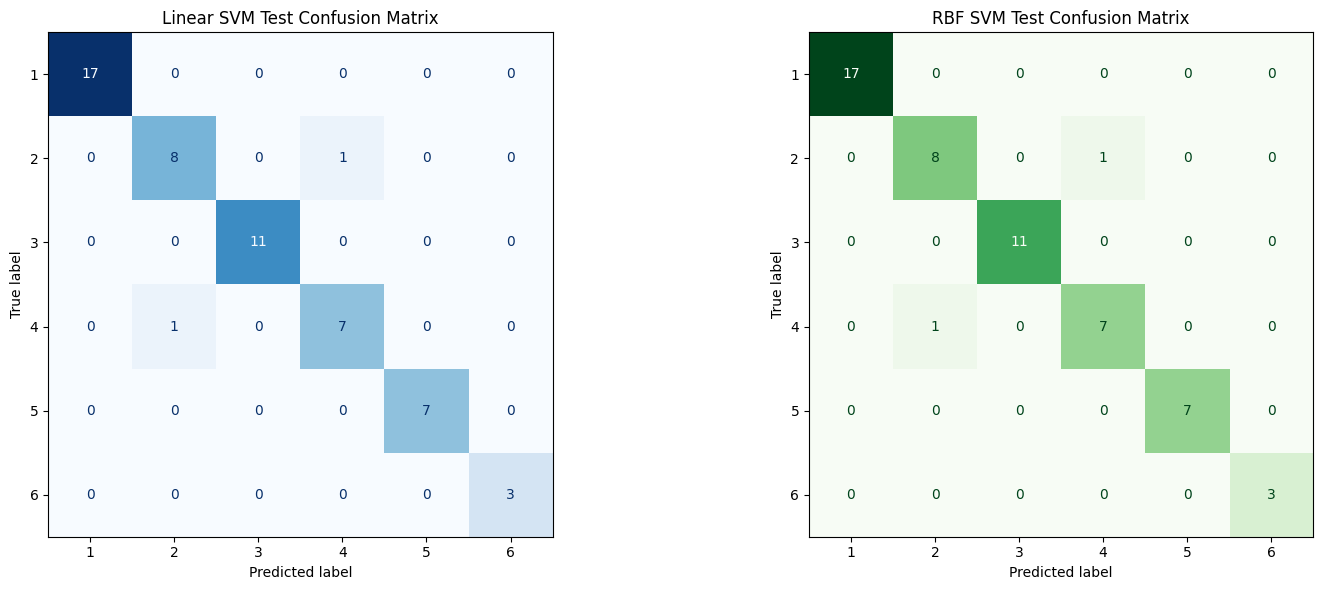

In [33]:
# Plot test-set confusion matrices for both tuned SVM models.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

linear_cm = confusion_matrix(svm_y_test, linear_test_predictions, labels=svm_class_labels)
rbf_cm = confusion_matrix(svm_y_test, rbf_test_predictions, labels=svm_class_labels)

ConfusionMatrixDisplay(confusion_matrix=linear_cm, display_labels=svm_class_labels).plot(
    ax=axes[0],
    cmap='Blues',
    colorbar=False
)
axes[0].set_title('Linear SVM Test Confusion Matrix')

ConfusionMatrixDisplay(confusion_matrix=rbf_cm, display_labels=svm_class_labels).plot(
    ax=axes[1],
    cmap='Greens',
    colorbar=False
)
axes[1].set_title('RBF SVM Test Confusion Matrix')

plt.tight_layout()
plt.show()


## SVM Model Summary and Justification

- The target variable `class` is categorical, so the task is classification rather than regression.
- Regression metrics are not reported because R2, MSE and MAE are not meaningful for disease class labels.
- Feature selection was performed before training using Sequential Feature Selection, and the selected SVM features were used for final SVM modeling.
- Two SVM models were constructed: Linear SVM and RBF SVM.
- Both models were fine-tuned with `GridSearchCV` using stratified 5-fold cross-validation.
- Accuracy, precision, recall, F1-score, classification report and confusion matrix were reported.
- The final model was selected using validation weighted F1-score because the dataset is imbalanced.

In [34]:
# Display the final chosen model and its tuned parameters for the report.
final_svm_summary = {
    'final_model': final_svm_model_name,
    'feature_source': svm_feature_source,
    'number_of_features': len(svm_selected_features_final),
    'selected_features': svm_selected_features_final,
    'final_model_parameters': final_svm_model.get_params()
}

print('Final SVM model summary')
print('Model:', final_svm_summary['final_model'])
print('Feature source:', final_svm_summary['feature_source'])
print('Number of features:', final_svm_summary['number_of_features'])
print('Selected features:', final_svm_summary['selected_features'])
print('Tuned parameters used by final model:')
print(final_svm_summary['final_model_parameters'])


Final SVM model summary
Model: RBF SVM
Feature source: SFS-selected features from the 70/15/15 split
Number of features: 20
Selected features: ['erythema', 'koebner_phenomenon', 'polygonal_papules', 'follicular_papules', 'oral_mucosal_involvement', 'knee_and_elbow_involvement', 'scalp_involvement', 'family_history', 'melanin_incontinence', 'PNL_infiltrate', 'fibrosis_of_the_papillary_dermis', 'exocytosis', 'hyperkeratosis', 'clubbing_of_the_rete_ridges', 'elongation_of_the_rete_ridges', 'thinning_of_the_suprapapillary_epidermis', 'focal_hypergranulosis', 'disappearance_of_the_granular_layer', 'spongiosis', 'perifollicular_parakeratosis']
Tuned parameters used by final model:
{'C': 1, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': -1, 'probability': False, 'random_state': 42, 'shrinking': True, 'tol': 0.001, 'verbose': False}
